In [29]:
# Import libraries that are needed
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [30]:
FILE_PATH = Path.cwd().parent / "datasets" / "placement.csv" # Generalized for any machine

In [31]:
df = pd.read_csv(FILE_PATH) # Import the dataset on which we are gonna perform linear regression on.
df.head() # Displays the top 5 elements of the dataset as default (we can pass the number of elements from above to be passed).

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


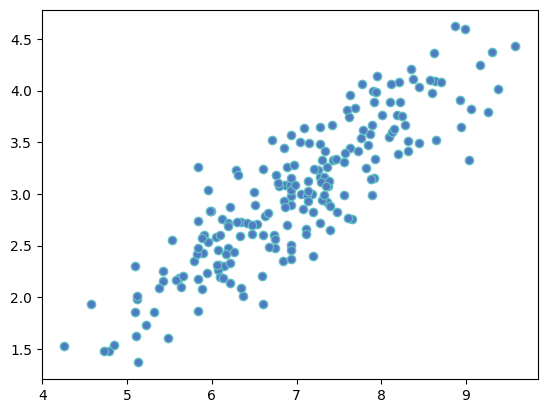

In [58]:
plt.scatter(df['cgpa'],df['package'],color="#507AC2",edgecolors="#61BEC3")
plt.show()
# After plotting the variables there seem to be a linear relationship that also with no far residuals
# This means we can use linear regression for this problem to capture the information in this graph
# and create such a generalized line that will be able to predict any point with minimal residual .

In [ ]:
# We fetch values here cause we want to apply numpy functions and we need a numpy array for that.
X = df.iloc[:,0:1].values
y = df.iloc[:,-1].values

In [33]:
type(X),type(y) # Displaying the type of the variables

(numpy.ndarray, numpy.ndarray)

In [34]:
# Now we will do train test split for experementing with our own model.
X_train , X_test , y_train , y_test = train_test_split ( 
    X , # The variables or features
    y, # The labels 
    test_size=0.2 , # The ratio of the test and train , accepts either value : train_size or test_size alternatively other is automatically selected.
    random_state=2 # Random state when values need to be reproduced 
)

In [35]:
X_train.shape[0] # Just a quick dimension check and fetching test to make sure things are going well till know.

160

In [36]:
# This method implemented below is called Ordinary Least Scores method .
# This is simple to implement and is a good choice for simple calculations. 
# For more insights you can check out how it is derived step by step.

In [37]:
# The equations derived were : 
'''
1. mean(y) - slope(m) * mean(x) = intercept (b)
2. slope(m) = summation(each element in y - mean(y).each element in x - mean(x)) / summation(square(each element in x - mean(x)))
'''


'\n1. mean(y) - slope(m) * mean(x) = intercept (b)\n2. slope(m) = summation(each element in y - mean(y).each element in x - mean(x)) / summation(square(each element in x - mean(x)))\n'

In [ ]:
# Using the Ordinary Least Squares : 
class LinearRegression:
    def __init__(self):
        # Constructor for creating :
        self.m = None  # Slope = 0 when instantiating
        self.b = None  # Intercept = 0 when instantiating
        self.X_test = None  # X_test instantiated

        # Fitting  : 
    def fit(self,X_train,y_train):
        n = 0 # Numerator of the equation 2
        d = 0 # Denominator of the equation 2
        # We do this to simplify the process of calcualtion .
        X_train_mean = np.mean(X_train) # Mean of X_train (X_bar)
        y_train_mean = np.mean(y_train) # Mean of y_train (y_bar)

        # Unlike gradient descent there is no nested looop
        # We simply train updated params n times (#rows) , so it is SGD but epoch = 1
        for x in range(X_train.shape[0]):
            # We need to iterate the loop to calculate and sum the numerator and denominator for all the X and y values . 
            n = n + ( X_train[x] - X_train_mean ) * (y_train[x] - y_train_mean ) # Iteratively sums the numerator using the formula
            d = d + ( X_train[x] - X_train_mean ) * ( X_train[x] - X_train_mean ) # Iteratively sums the denominator using the formula

        # Now we divide the numerator by the denominator (equation2 )to get slope and store it as an object .
        self.m = n/d  
        self.b = y_train_mean - self.m * X_train_mean # Similary get the intercept by the equation 1.
        
        print(f"Slope is : {self.m} ")
        print(f"Intercept is : {self.b} ")

    # Predict using the line equation : y = m*x + b
    def predict(self,X_test):
        # This here is a simple linear product and no other activation function is applied to it .
        return (self.m * X_test + self.b)

    

In [39]:
model = LinearRegression() # Instantiate the model

In [40]:
model.fit(X_train,y_train) # Fit the training features and labels

Slope is : [0.55795197] 
Intercept is : [-0.89611192] 


In [ ]:
y_pred = model.predict(X_test) # predictions for X_test according to the model

In [42]:
# Residual Analysis
residual = y_test - y_pred  # Residuals are differences in actual and machine predictions 
residual.sum(),residual.mean() # The summation and the mean of it.

(np.float64(-65.61078388041219), np.float64(-0.041006739925257614))

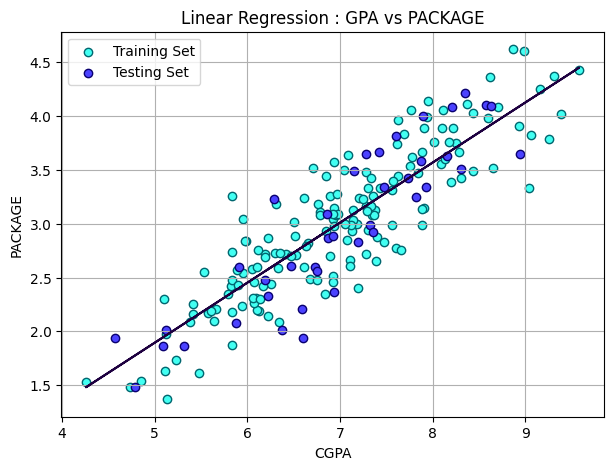

In [43]:
# Now lets fit a line using the model's prediction on X.
plt.figure(figsize=(7,5))
plt.grid(visible=True,axis='both')
plt.scatter(X_train,y_train,color="#42FFF2",edgecolor="#00666F",label='Training Set')
plt.scatter(X_test,y_test,color="#4B42FF",edgecolor="#09006F",label='Testing Set')
plt.plot(X,model.predict(X),color="#1E0040")
plt.xlabel('CGPA')
plt.ylabel('PACKAGE')
plt.title('Linear Regression : GPA vs PACKAGE')
plt.legend()
plt.show()

In [56]:
# Evaluation
# The model fairly fits well on the given testing points 
# Maybe a slightly polynomial curve would have fit better I guess

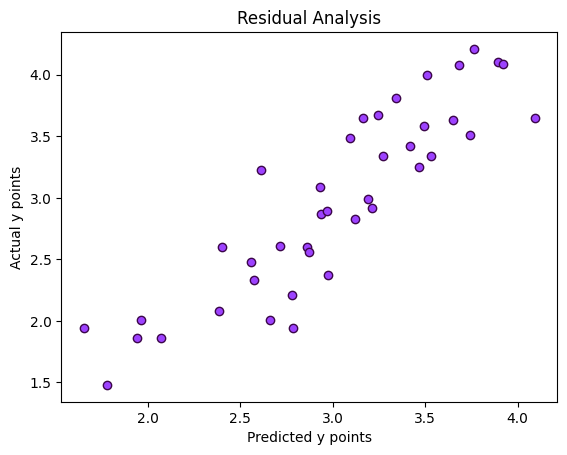

In [60]:
# Residual Analysis - Peeking at the residuals to look whether there is a linear pattern or not
plt.scatter(y_pred,y_test,color="#9D42FF",edgecolor="#3B064A")
plt.xlabel('Predicted y points')
plt.ylabel('Actual y points')
plt.title('Residual Analysis')
plt.show()

In [61]:
# We either need a more data or a better model like PolynomialRegression , RandomForest for better performance